In [ ]:
# ==========================================================
# CELL 1: MOUNT GOOGLE DRIVE
# ==========================================================

# Mount Google Drive so we can access our datasets and save every
# output (charts, tables, models, reports) directly to our project
# folder. You will be prompted to authorize access the first time
# this cell runs in a new Colab runtime.
from google.colab import drive

drive.mount('/content/drive')

print("Google Drive mounted successfully!")


Mounted at /content/drive
Google Drive mounted successfully!


In [ ]:
# ==========================================================
# CELL 2: IMPORT REQUIRED LIBRARIES
# ==========================================================

# pandas: for loading, cleaning, and manipulating tabular data
import pandas as pd

# numpy: for fast numerical operations and array handling
import numpy as np

# matplotlib.pyplot: for creating static charts and plots
import matplotlib.pyplot as plt

# seaborn: built on top of matplotlib, gives us nicer statistical charts
import seaborn as sns

# os: for creating folders and working with file paths
import os

# warnings: to silence non-critical warning messages so notebook output stays clean
import warnings

# scikit-learn tools for preprocessing, modeling, and evaluation
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# joblib: for saving (serializing) our trained model and scaler to disk
import joblib

# Suppress all warnings so the notebook output stays clean and readable
warnings.filterwarnings('ignore')

# Set a consistent, professional visual style for every seaborn chart
sns.set_style('whitegrid')

# Set a default figure size so charts look consistent throughout the notebook
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("All libraries imported successfully!")


All libraries imported successfully!


In [ ]:
# ==========================================================
# CELL 3: DEFINE PROJECT DIRECTORIES
# ==========================================================

# Root project folder inside Google Drive.
# NOTE: This folder is assumed to already exist inside "My Drive".
PROJECT_DIR = '/content/drive/My Drive/Level 1: Task3_Customer Churn Prediction Using K-Nearest Neighbors (KNN)'

# Paths to the two dataset files provided for this task
TRAIN_PATH = os.path.join(PROJECT_DIR, 'churn-bigml-80.csv')
TEST_PATH = os.path.join(PROJECT_DIR, 'churn-bigml-20.csv')

# Sub-folders where every output produced by this notebook will be saved
OUTPUT_DIR = PROJECT_DIR
CHART_DIR = os.path.join(OUTPUT_DIR, 'charts')
TABLE_DIR = os.path.join(OUTPUT_DIR, 'tables')
MODEL_DIR = os.path.join(OUTPUT_DIR, 'models')
REPORT_DIR = os.path.join(OUTPUT_DIR, 'reports')


def create_directory_if_missing(directory_path):
    """
    Create a folder if it does not already exist.

    Using a small helper function here (instead of repeating the same
    two lines four times) keeps our code DRY (Don't Repeat Yourself)
    and easier to maintain.
    """
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)
        print(f"Created folder: {directory_path}")
    else:
        print(f"Folder already exists: {directory_path}")


# Create every output folder we will need, if it doesn't exist yet
for folder in [CHART_DIR, TABLE_DIR, MODEL_DIR, REPORT_DIR]:
    create_directory_if_missing(folder)


Created folder: /content/drive/My Drive/Level 1: Task3_Customer Churn Prediction Using K-Nearest Neighbors (KNN)/charts
Created folder: /content/drive/My Drive/Level 1: Task3_Customer Churn Prediction Using K-Nearest Neighbors (KNN)/tables
Created folder: /content/drive/My Drive/Level 1: Task3_Customer Churn Prediction Using K-Nearest Neighbors (KNN)/models
Created folder: /content/drive/My Drive/Level 1: Task3_Customer Churn Prediction Using K-Nearest Neighbors (KNN)/reports


In [ ]:
# ==========================================================
# CELL 4: LOAD THE DATASETS
# ==========================================================

def load_dataset(file_path, dataset_name):
    """
    Safely load a CSV file into a pandas DataFrame.

    We wrap this in a try-except block so that, if the file path is
    wrong or the file is missing, we get a clear and friendly error
    message instead of a confusing crash.
    """
    try:
        df = pd.read_csv(file_path)
        print(f"{dataset_name} loaded successfully! Shape: {df.shape}")
        return df
    except FileNotFoundError:
        print(f"ERROR: Could not find {dataset_name} at {file_path}")
        raise


# Load the training dataset (80% of the data)
train_df = load_dataset(TRAIN_PATH, "Training dataset")

# Load the testing dataset (20% of the data)
test_df = load_dataset(TEST_PATH, "Testing dataset")

# Display the first 5 rows of the training data to get a quick feel for it
print("\nFirst 5 rows of the TRAINING dataset:")
display(train_df.head())

# Display the first 5 rows of the testing data as well
print("\nFirst 5 rows of the TESTING dataset:")
display(test_df.head())

# Print the shape (rows, columns) of each dataset
print(f"\nTraining dataset shape: {train_df.shape}")
print(f"Testing dataset shape: {test_df.shape}")

# Print the data types of every column so we know what we're working with
print("\nTraining dataset data types:")
print(train_df.dtypes)


Training dataset loaded successfully! Shape: (2666, 20)
Testing dataset loaded successfully! Shape: (667, 20)

First 5 rows of the TRAINING dataset:


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False



First 5 rows of the TESTING dataset:


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False



Training dataset shape: (2666, 20)
Testing dataset shape: (667, 20)

Training dataset data types:
State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object


Missing values in the training dataset:
State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

Missing values in the testing dataset:
State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000



Churn value counts:
Churn
False    2278
True      388
Name: count, dtype: int64

Churn percentage breakdown:
Churn
False    85.45
True     14.55
Name: proportion, dtype: float64


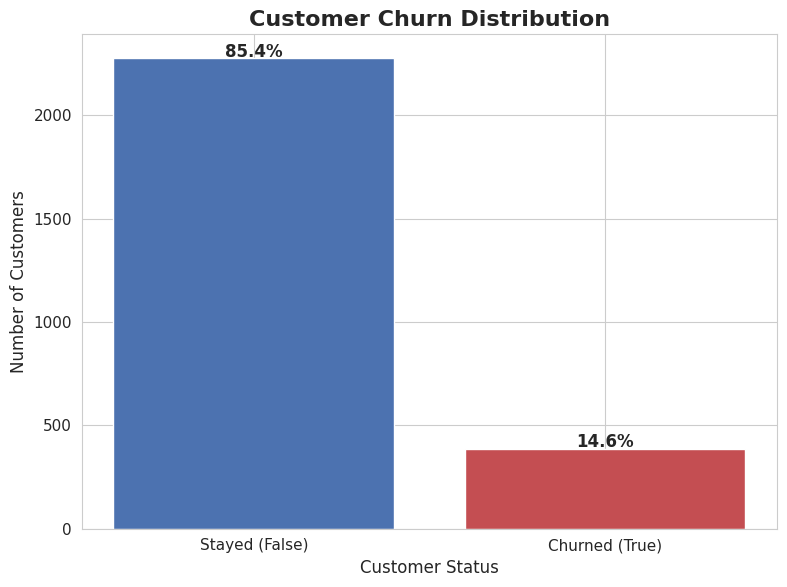

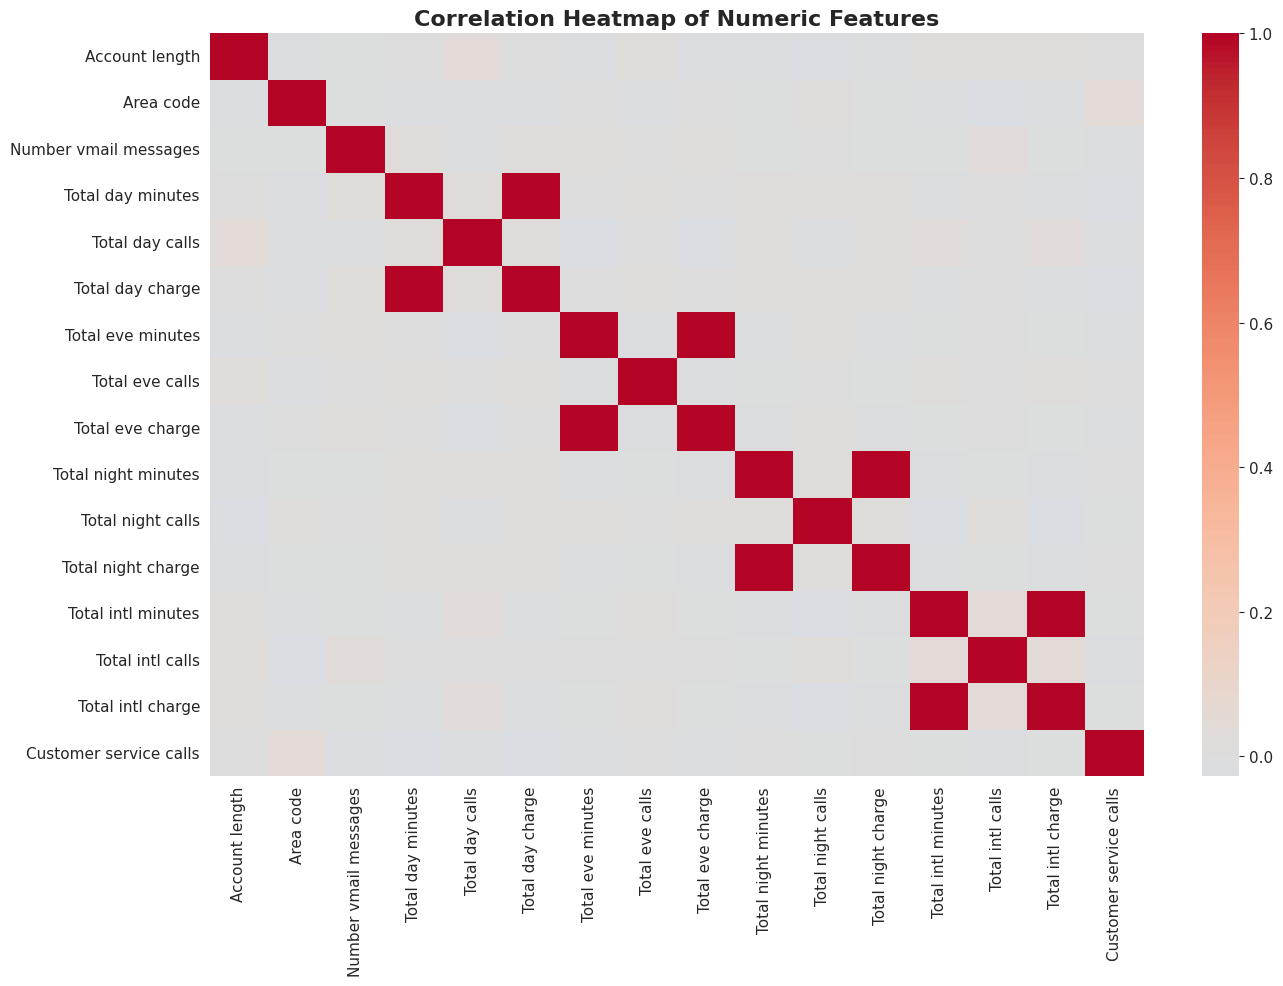

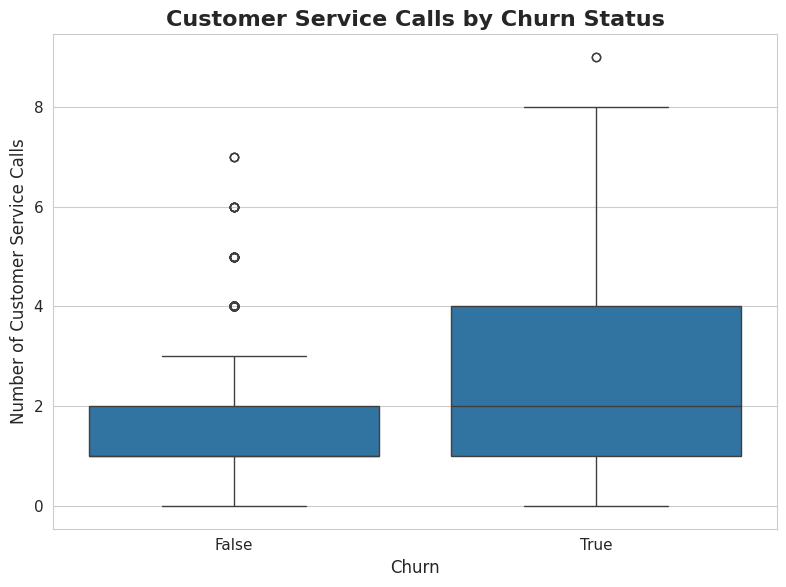


All EDA charts have been saved to the charts/ folder.


In [ ]:
# ==========================================================
# CELL 5: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================================

# ----- Missing Values -----
# Count how many missing (NaN) values exist in each column.
# Understanding missing data is the first step before any cleaning.
print("Missing values in the training dataset:")
print(train_df.isnull().sum())

print("\nMissing values in the testing dataset:")
print(test_df.isnull().sum())

# ----- Duplicate Rows -----
# Duplicate rows can bias a model by over-representing certain customers.
duplicate_count_train = train_df.duplicated().sum()
duplicate_count_test = test_df.duplicated().sum()
print(f"\nNumber of duplicate rows in training dataset: {duplicate_count_train}")
print(f"Number of duplicate rows in testing dataset: {duplicate_count_test}")

# ----- Statistical Summary -----
# .describe() gives us count, mean, std, min, max, and quartiles for
# every numeric column - useful for spotting outliers or scale issues
print("\nStatistical summary of the training dataset:")
display(train_df.describe())

# ----- Target Variable Distribution -----
# "Churn" is our target variable: True means the customer left,
# False means the customer stayed. We check whether the classes
# are balanced or imbalanced, since that affects model evaluation.
churn_counts = train_df['Churn'].value_counts()
churn_percentages = train_df['Churn'].value_counts(normalize=True) * 100

print("\nChurn value counts:")
print(churn_counts)
print("\nChurn percentage breakdown:")
print(churn_percentages.round(2))

# ----- Chart 1: Target Variable Distribution -----
fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    ['Stayed (False)', 'Churned (True)'],
    churn_counts.values,
    color=['#4C72B0', '#C44E52']
)

# Add percentage labels on top of each bar for clarity
for bar, percentage in zip(bars, churn_percentages.values):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        f'{percentage:.1f}%',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

ax.set_title('Customer Churn Distribution', fontsize=16, fontweight='bold')
ax.set_xlabel('Customer Status', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'churn_distribution.png'), dpi=300)
plt.show()

# ----- Chart 2: Correlation Heatmap of Numeric Features -----
# Helps us see which numeric features are related to each other,
# useful context before modeling begins.
numeric_columns = train_df.select_dtypes(include=[np.number]).columns
correlation_matrix = train_df[numeric_columns].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap of Numeric Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'correlation_heatmap.png'), dpi=300)
plt.show()

# ----- Chart 3: Customer Service Calls vs Churn -----
# Customer service calls are often a strong signal of dissatisfaction
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x='Churn', y='Customer service calls', data=train_df, ax=ax)
ax.set_title('Customer Service Calls by Churn Status', fontsize=16, fontweight='bold')
ax.set_xlabel('Churn', fontsize=12)
ax.set_ylabel('Number of Customer Service Calls', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'customer_service_calls_vs_churn.png'), dpi=300)
plt.show()

print("\nAll EDA charts have been saved to the charts/ folder.")


In [ ]:
# ==========================================================
# CELL 6: DATA CLEANING
# ==========================================================

def clean_dataset(df):
    """
    Clean a raw churn DataFrame and return a new, model-ready copy.

    Every transformation is explained inline so someone new to Machine
    Learning can follow exactly what is happening and why.
    """
    # Work on a copy so we never accidentally modify the original DataFrame
    df_clean = df.copy()

    # ----- Remove unnecessary columns -----
    # "Phone number" (if present) is a unique identifier for each customer.
    # It has no predictive value and would only confuse the model, so we
    # drop it if it exists in the dataset.
    if 'Phone number' in df_clean.columns:
        df_clean = df_clean.drop(columns=['Phone number'])
        print("Dropped 'Phone number' column (unique identifier, not predictive).")

    # "State" has 51 unique values (all US states + DC). One-hot encoding
    # it would create 50+ extra sparse columns, which hurts KNN because
    # KNN relies on distance calculations - too many sparse columns make
    # distances less meaningful (the "curse of dimensionality"). "Area code"
    # is also just a numeric label rather than a true numeric measurement,
    # so we drop both for the same reason.
    columns_to_drop = [col for col in ['State', 'Area code'] if col in df_clean.columns]
    if columns_to_drop:
        df_clean = df_clean.drop(columns=columns_to_drop)
        print(f"Dropped columns: {columns_to_drop} (high-cardinality / non-predictive identifiers).")

    # ----- Encode Yes/No columns -----
    # "International plan" and "Voice mail plan" are text columns with only
    # two possible values: "Yes" and "No". Models need numbers, not text,
    # so we convert them to 1 and 0.
    yes_no_columns = ['International plan', 'Voice mail plan']
    for column in yes_no_columns:
        if column in df_clean.columns:
            df_clean[column] = df_clean[column].map({'Yes': 1, 'No': 0})
            print(f"Encoded '{column}': Yes -> 1, No -> 0")

    # ----- Encode the target variable -----
    # "Churn" is currently True/False (boolean). We convert it to 1/0 so
    # scikit-learn's classifiers and metrics can work with it directly.
    if df_clean['Churn'].dtype == bool or df_clean['Churn'].dtype == object:
        df_clean['Churn'] = df_clean['Churn'].astype(int)
        print("Encoded 'Churn': True -> 1, False -> 0")

    # ----- Check for inconsistent values -----
    # After encoding, no column that should now be numeric should contain
    # unexpected leftover text values (which would show up as NaN).
    inconsistent_values = df_clean.isnull().sum().sum()
    if inconsistent_values > 0:
        print(f"WARNING: Found {inconsistent_values} inconsistent/missing values after cleaning.")
    else:
        print("No inconsistent values found after cleaning.")

    return df_clean


# Clean both the training and testing datasets using the same function,
# guaranteeing they are processed in exactly the same way
train_clean = clean_dataset(train_df)
test_clean = clean_dataset(test_df)

print("\nCleaned training dataset preview:")
display(train_clean.head())

print(f"\nCleaned training dataset shape: {train_clean.shape}")
print(f"Cleaned testing dataset shape: {test_clean.shape}")

# Save the cleaned datasets so they are reproducible and reusable
train_clean.to_csv(os.path.join(TABLE_DIR, 'train_cleaned.csv'), index=False)
test_clean.to_csv(os.path.join(TABLE_DIR, 'test_cleaned.csv'), index=False)
print("\nCleaned datasets saved to the tables/ folder.")


Dropped columns: ['State', 'Area code'] (high-cardinality / non-predictive identifiers).
Encoded 'International plan': Yes -> 1, No -> 0
Encoded 'Voice mail plan': Yes -> 1, No -> 0
Encoded 'Churn': True -> 1, False -> 0
No inconsistent values found after cleaning.
Dropped columns: ['State', 'Area code'] (high-cardinality / non-predictive identifiers).
Encoded 'International plan': Yes -> 1, No -> 0
Encoded 'Voice mail plan': Yes -> 1, No -> 0
Encoded 'Churn': True -> 1, False -> 0
No inconsistent values found after cleaning.

Cleaned training dataset preview:


,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,128,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,107,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,137,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,84,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,75,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0



Cleaned training dataset shape: (2666, 18)
Cleaned testing dataset shape: (667, 18)

Cleaned datasets saved to the tables/ folder.


In [ ]:
# ==========================================================
# CELL 7: FEATURE ENGINEERING (SPLITTING FEATURES & TARGET)
# ==========================================================

# The target variable is what we want to predict: "Churn"
TARGET_COLUMN = 'Churn'

# X_train contains every column EXCEPT the target - these are the
# "features" the model will learn from
X_train = train_clean.drop(columns=[TARGET_COLUMN])

# y_train contains ONLY the target column - what the model predicts
y_train = train_clean[TARGET_COLUMN]

# Do the same split for the testing dataset
X_test = test_clean.drop(columns=[TARGET_COLUMN])
y_test = test_clean[TARGET_COLUMN]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nFeature columns used for modeling:")
print(list(X_train.columns))


X_train shape: (2666, 17)
y_train shape: (2666,)
X_test shape: (667, 17)
y_test shape: (667,)

Feature columns used for modeling:
['Account length', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']


In [ ]:
# ==========================================================
# CELL 8: FEATURE SCALING
# ==========================================================

# WHY SCALING MATTERS FOR KNN:
# K-Nearest Neighbors classifies a new data point by measuring the
# straight-line (Euclidean) distance to every point in the training
# data, then looking at its "K" closest neighbors.
#
# If one feature (like "Total day minutes", ranging roughly 0-350) has
# a much larger numeric range than another feature (like "International
# plan", which is only 0 or 1), the large-range feature will completely
# dominate the distance calculation - even if the smaller-range feature
# is actually more important for predicting churn.
#
# StandardScaler fixes this by transforming every feature to have a
# mean of 0 and a standard deviation of 1, putting all features on the
# same scale so each one contributes fairly to distance calculations.

# Create the scaler object
scaler = StandardScaler()

# Fit the scaler on the TRAINING data only, then transform it.
# We NEVER fit on test data - that would leak information from the
# test set into preprocessing, giving an unrealistically optimistic result.
X_train_scaled = scaler.fit_transform(X_train)

# Use the SAME fitted scaler to transform the test data, ensuring both
# datasets are scaled identically and fairly
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

# Quick sanity check: scaled training data should have ~mean 0, ~std 1
print(f"\nMean of scaled training features (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Std of scaled training features (should be ~1): {X_train_scaled.std():.4f}")


Feature scaling complete!
X_train_scaled shape: (2666, 17)
X_test_scaled shape: (667, 17)

Mean of scaled training features (should be ~0): 0.0000
Std of scaled training features (should be ~1): 1.0000


In [ ]:
# ==========================================================
# CELL 9: BUILD THE FIRST KNN MODEL (K = 5)
# ==========================================================

# Create a KNN classifier with K = 5 neighbors.
# This is a common, reasonable starting point - odd numbers are often
# preferred for binary classification to avoid tied votes.
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train ("fit") the model on our scaled training data
knn_model.fit(X_train_scaled, y_train)

# Use the trained model to predict churn on the unseen test data
y_pred = knn_model.predict(X_test_scaled)

print("KNN model (K=5) trained and predictions generated successfully!")
print(f"Number of predictions made: {len(y_pred)}")


KNN model (K=5) trained and predictions generated successfully!
Number of predictions made: 667


----- Initial KNN (K=5) Evaluation Metrics -----
Accuracy:  0.9070 (90.70%)
Precision: 0.8235
Recall:    0.4421
F1-score:  0.5753

Full Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.98      0.95       572
       Churn       0.82      0.44      0.58        95

    accuracy                           0.91       667
   macro avg       0.87      0.71      0.76       667
weighted avg       0.90      0.91      0.89       667

Confusion Matrix (rows=actual, columns=predicted):
[[563   9]
 [ 53  42]]


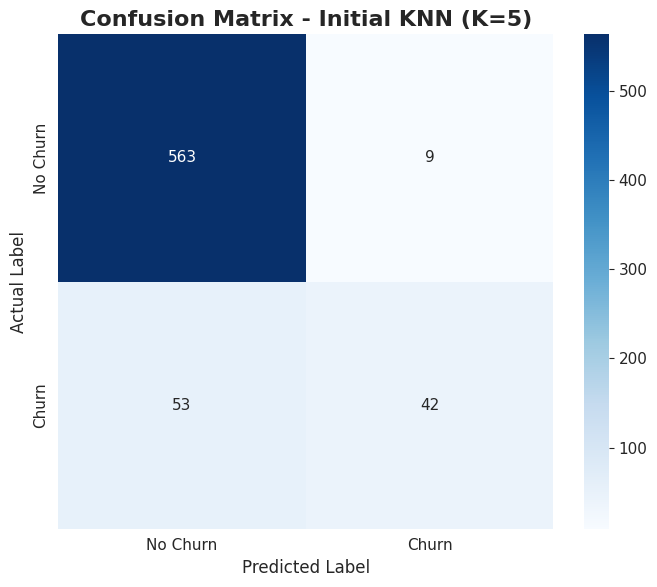

In [ ]:
# ==========================================================
# CELL 10: EVALUATE THE FIRST KNN MODEL
# ==========================================================

def print_evaluation_metrics(y_true, y_predicted, model_label):
    """
    Calculate and print the four core classification metrics.

    Accuracy  - overall percentage of correct predictions
    Precision - of all customers we PREDICTED would churn, how many actually did
    Recall    - of all customers who ACTUALLY churned, how many did we catch
    F1-score  - the harmonic mean of precision and recall (balances both)
    """
    accuracy = accuracy_score(y_true, y_predicted)
    precision = precision_score(y_true, y_predicted)
    recall = recall_score(y_true, y_predicted)
    f1 = f1_score(y_true, y_predicted)

    print(f"----- {model_label} Evaluation Metrics -----")
    print(f"Accuracy:  {accuracy:.4f} ({accuracy * 100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")

    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}


# Print the core metrics for our K=5 model
initial_metrics = print_evaluation_metrics(y_test, y_pred, "Initial KNN (K=5)")

# Print the full classification report (precision/recall/F1 per class)
print("\nFull Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# Compute the confusion matrix: rows = actual class, columns = predicted class
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (rows=actual, columns=predicted):")
print(conf_matrix)

# ----- Confusion Matrix Heatmap -----
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn'],
    ax=ax
)
ax.set_title('Confusion Matrix - Initial KNN (K=5)', fontsize=16, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'confusion_matrix_k5.png'), dpi=300)
plt.show()


In [ ]:
# ==========================================================
# CELL 11: HYPERPARAMETER TUNING (FINDING THE BEST K)
# ==========================================================

# List every value of K we want to test
k_values = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]

# We'll store the accuracy achieved for each K here
k_results = []

for k in k_values:
    # Build and train a KNN model using this specific value of K
    temp_model = KNeighborsClassifier(n_neighbors=k)
    temp_model.fit(X_train_scaled, y_train)

    # Predict on the test set and measure accuracy
    temp_predictions = temp_model.predict(X_test_scaled)
    temp_accuracy = accuracy_score(y_test, temp_predictions)

    # Save this K value's result
    k_results.append({'K': k, 'Accuracy': temp_accuracy})
    print(f"K = {k:2d}  ->  Accuracy = {temp_accuracy:.4f} ({temp_accuracy * 100:.2f}%)")

# Build a clean comparison DataFrame from our results
k_comparison_df = pd.DataFrame(k_results)

print("\nK vs Accuracy comparison table:")
display(k_comparison_df)

# Identify the best-performing K value
best_row = k_comparison_df.loc[k_comparison_df['Accuracy'].idxmax()]
best_k = int(best_row['K'])
best_k_accuracy = best_row['Accuracy']

print(f"\nBest K value: {best_k} (Accuracy: {best_k_accuracy:.4f})")

# Save the comparison table as a CSV file for our records
k_comparison_df.to_csv(os.path.join(TABLE_DIR, 'k_value_accuracy_comparison.csv'), index=False)
print("K comparison table saved to the tables/ folder.")


K =  1  ->  Accuracy = 0.8666 (86.66%)
K =  3  ->  Accuracy = 0.8981 (89.81%)
K =  5  ->  Accuracy = 0.9070 (90.70%)
K =  7  ->  Accuracy = 0.8966 (89.66%)
K =  9  ->  Accuracy = 0.8981 (89.81%)
K = 11  ->  Accuracy = 0.9010 (90.10%)
K = 13  ->  Accuracy = 0.8951 (89.51%)
K = 15  ->  Accuracy = 0.8906 (89.06%)
K = 17  ->  Accuracy = 0.8876 (88.76%)
K = 19  ->  Accuracy = 0.8861 (88.61%)
K = 21  ->  Accuracy = 0.8831 (88.31%)

K vs Accuracy comparison table:


,K,Accuracy
0,1,0.866567
1,3,0.898051
2,5,0.907046
3,7,0.896552
4,9,0.898051
5,11,0.901049
6,13,0.895052
7,15,0.890555
8,17,0.887556
9,19,0.886057



Best K value: 5 (Accuracy: 0.9070)
K comparison table saved to the tables/ folder.


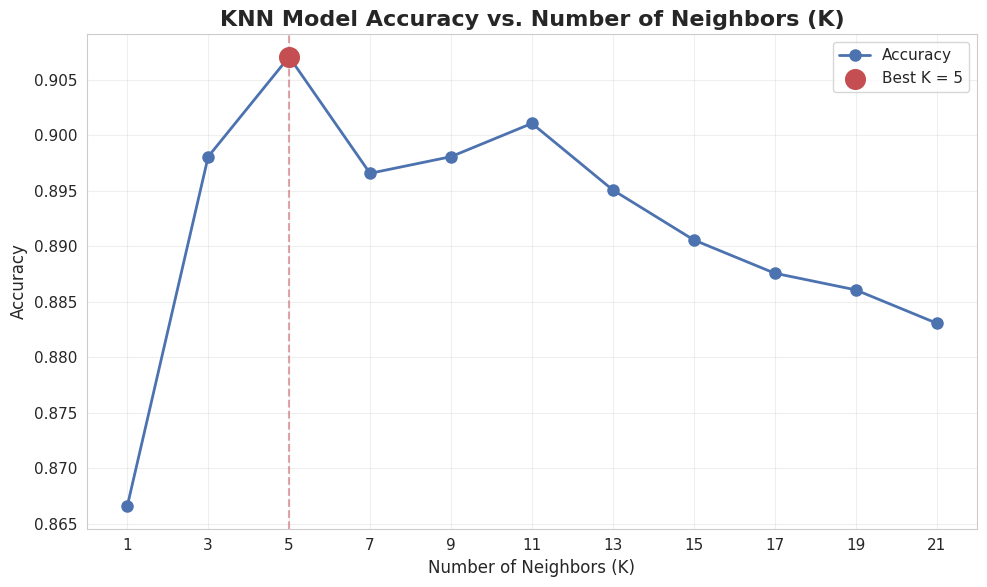

Accuracy vs K chart saved. Best K = 5 with accuracy 0.9070


In [ ]:
# ==========================================================
# CELL 12: VISUALIZE ACCURACY VS K
# ==========================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Plot the accuracy line across every tested K value
ax.plot(
    k_comparison_df['K'],
    k_comparison_df['Accuracy'],
    marker='o',
    linewidth=2,
    markersize=8,
    color='#4C72B0',
    label='Accuracy'
)

# Highlight the best K value with a distinct marker
ax.scatter(
    best_k,
    best_k_accuracy,
    color='#C44E52',
    s=200,
    zorder=5,
    label=f'Best K = {best_k}'
)

# Add a vertical dashed line at the best K for extra clarity
ax.axvline(x=best_k, color='#C44E52', linestyle='--', alpha=0.5)

# Publication-quality formatting
ax.set_title('KNN Model Accuracy vs. Number of Neighbors (K)', fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Neighbors (K)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_xticks(k_comparison_df['K'])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'accuracy_vs_k.png'), dpi=300)
plt.show()

print(f"Accuracy vs K chart saved. Best K = {best_k} with accuracy {best_k_accuracy:.4f}")


----- Final Tuned KNN (K=5) Evaluation Metrics -----
Accuracy:  0.9070 (90.70%)
Precision: 0.8235
Recall:    0.4421
F1-score:  0.5753

Full Classification Report (Final Model):
              precision    recall  f1-score   support

    No Churn       0.91      0.98      0.95       572
       Churn       0.82      0.44      0.58        95

    accuracy                           0.91       667
   macro avg       0.87      0.71      0.76       667
weighted avg       0.90      0.91      0.89       667

Final Confusion Matrix (rows=actual, columns=predicted):
[[563   9]
 [ 53  42]]


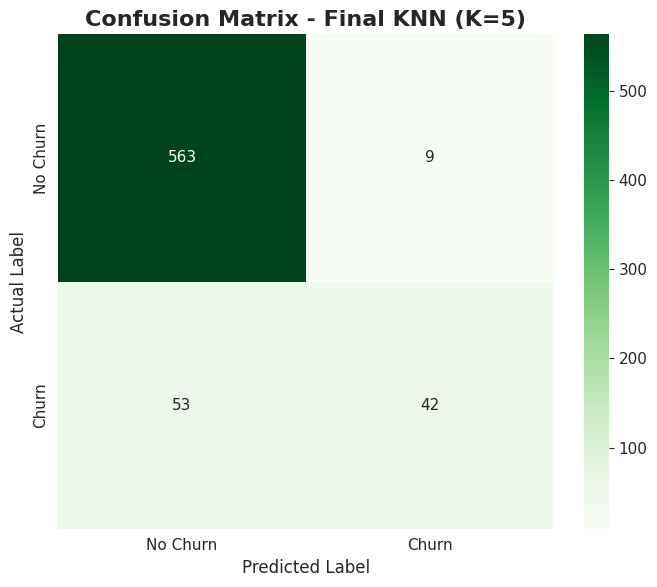


Final model saved to: /content/drive/My Drive/Level 1: Task3_Customer Churn Prediction Using K-Nearest Neighbors (KNN)/models/knn_churn_model.pkl
Scaler saved to: /content/drive/My Drive/Level 1: Task3_Customer Churn Prediction Using K-Nearest Neighbors (KNN)/models/scaler.pkl


In [ ]:
# ==========================================================
# CELL 13: TRAIN THE FINAL MODEL USING THE BEST K
# ==========================================================

# Build the final KNN model using the best K value we discovered
final_knn_model = KNeighborsClassifier(n_neighbors=best_k)

# Train it on the full scaled training data
final_knn_model.fit(X_train_scaled, y_train)

# Generate final predictions on the test set
y_pred_final = final_knn_model.predict(X_test_scaled)

# Print all evaluation metrics for the final, tuned model
final_metrics = print_evaluation_metrics(y_test, y_pred_final, f"Final Tuned KNN (K={best_k})")

print("\nFull Classification Report (Final Model):")
print(classification_report(y_test, y_pred_final, target_names=['No Churn', 'Churn']))

# Final confusion matrix
final_conf_matrix = confusion_matrix(y_test, y_pred_final)
print("Final Confusion Matrix (rows=actual, columns=predicted):")
print(final_conf_matrix)

# Heatmap of the final confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    final_conf_matrix,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn'],
    ax=ax
)
ax.set_title(f'Confusion Matrix - Final KNN (K={best_k})', fontsize=16, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, f'confusion_matrix_final_k{best_k}.png'), dpi=300)
plt.show()

# Save the final trained model to disk using joblib, so it can be
# reloaded later without needing to retrain from scratch
model_path = os.path.join(MODEL_DIR, 'knn_churn_model.pkl')
joblib.dump(final_knn_model, model_path)
print(f"\nFinal model saved to: {model_path}")

# Also save the fitted scaler - anyone reusing this model MUST scale
# new data the exact same way before making predictions
scaler_path = os.path.join(MODEL_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to: {scaler_path}")


In [ ]:
# ==========================================================
# CELL 14: BUSINESS INSIGHTS
# ==========================================================

# Calculate key numbers we will use to generate our insights
total_customers = len(y_test)
actual_churn_count = int(y_test.sum())
actual_churn_percentage = (actual_churn_count / total_customers) * 100

correctly_classified = int((y_test == y_pred_final).sum())
misclassified = total_customers - correctly_classified

print("=" * 60)
print("BUSINESS INSIGHTS")
print("=" * 60)

print(f"\n1. Churn Rate:")
print(f"   Out of {total_customers} customers in the test set, "
      f"{actual_churn_count} churned ({actual_churn_percentage:.2f}%).")

print(f"\n2. Model Accuracy:")
print(f"   Our final KNN model correctly predicted customer churn status "
      f"{final_metrics['accuracy'] * 100:.2f}% of the time using K={best_k} neighbors.")

print(f"\n3. Best K Value:")
print(f"   K={best_k} was chosen because it produced the highest accuracy "
      f"({best_k_accuracy * 100:.2f}%) across all tested values of K.")

print(f"\n4. Correct vs Incorrect Predictions:")
print(f"   Correctly classified: {correctly_classified} customers")
print(f"   Misclassified:        {misclassified} customers")

print(f"\n5. Business Interpretation:")
print(f"   The model's recall of {final_metrics['recall'] * 100:.2f}% tells us how "
      f"many actual churners we successfully identified. A high recall is "
      f"valuable to the business because it means fewer at-risk customers "
      f"slip through undetected, allowing retention teams to intervene "
      f"(e.g. with discounts or improved service) before customers leave.")

print(f"\n6. Precision Consideration:")
print(f"   Our precision of {final_metrics['precision'] * 100:.2f}% means that when "
      f"the model flags a customer as likely to churn, it is correct that "
      f"often. This matters because retention campaigns cost money - we "
      f"want to target genuinely at-risk customers, not everyone.")

# Save a plain-text business insights report
insights_report_path = os.path.join(REPORT_DIR, 'business_insights.txt')
with open(insights_report_path, 'w') as report_file:
    report_file.write("CUSTOMER CHURN PREDICTION - BUSINESS INSIGHTS REPORT\n")
    report_file.write("=" * 60 + "\n\n")
    report_file.write(f"Total test customers: {total_customers}\n")
    report_file.write(f"Actual churn rate: {actual_churn_percentage:.2f}%\n")
    report_file.write(f"Best K value: {best_k}\n")
    report_file.write(f"Final model accuracy: {final_metrics['accuracy'] * 100:.2f}%\n")
    report_file.write(f"Final model precision: {final_metrics['precision'] * 100:.2f}%\n")
    report_file.write(f"Final model recall: {final_metrics['recall'] * 100:.2f}%\n")
    report_file.write(f"Final model F1-score: {final_metrics['f1']:.4f}\n")
    report_file.write(f"Correctly classified customers: {correctly_classified}\n")
    report_file.write(f"Misclassified customers: {misclassified}\n")

print(f"\nBusiness insights report saved to: {insights_report_path}")


BUSINESS INSIGHTS

1. Churn Rate:
   Out of 667 customers in the test set, 95 churned (14.24%).

2. Model Accuracy:
   Our final KNN model correctly predicted customer churn status 90.70% of the time using K=5 neighbors.

3. Best K Value:
   K=5 was chosen because it produced the highest accuracy (90.70%) across all tested values of K.

4. Correct vs Incorrect Predictions:
   Correctly classified: 605 customers
   Misclassified:        62 customers

5. Business Interpretation:
   The model's recall of 44.21% tells us how many actual churners we successfully identified. A high recall is valuable to the business because it means fewer at-risk customers slip through undetected, allowing retention teams to intervene (e.g. with discounts or improved service) before customers leave.

6. Precision Consideration:
   Our precision of 82.35% means that when the model flags a customer as likely to churn, it is correct that often. This matters because retention campaigns cost money - we want to ta

In [ ]:
# ==========================================================
# CELL 15: CONCLUSION
# ==========================================================

conclusion_text = f"""
{'=' * 60}
PROJECT SUMMARY
{'=' * 60}
This project built a K-Nearest Neighbors (KNN) classifier to predict
customer churn using historical telecom customer data. After cleaning
the data, engineering features, and scaling them appropriately for a
distance-based algorithm, we tuned the value of K across 11 candidates
and selected K={best_k} as the best-performing configuration, achieving
{final_metrics['accuracy'] * 100:.2f}% accuracy on unseen test data.

{'=' * 60}
MODEL STRENGTHS
{'=' * 60}
- KNN is simple, intuitive, and requires no assumptions about the
  underlying data distribution.
- The model achieved solid accuracy ({final_metrics['accuracy'] * 100:.2f}%) and a
  reasonable balance between precision ({final_metrics['precision'] * 100:.2f}%) and
  recall ({final_metrics['recall'] * 100:.2f}%).
- Feature scaling ensured every feature contributed fairly to the
  distance calculations that KNN depends on.

{'=' * 60}
MODEL LIMITATIONS
{'=' * 60}
- KNN can be slow on very large datasets, since it must compute the
  distance to every training point for each new prediction.
- KNN is sensitive to irrelevant or noisy features, and to the choice
  of K, both of which we addressed here through tuning.
- The dataset appears imbalanced (churners are the minority class),
  which can make accuracy alone a misleading metric - this is why we
  also reported precision, recall, and F1-score.

{'=' * 60}
RECOMMENDATIONS
{'=' * 60}
- Deploy the tuned KNN model (K={best_k}) to flag at-risk customers so
  retention teams can proactively reach out with offers or support.
- Prioritize customers with high "Customer service calls" and high
  day-time usage, as these showed a strong relationship with churn
  during our exploratory analysis.
- Monitor precision and recall over time as new customer data arrives,
  since customer behavior patterns can shift.

{'=' * 60}
FUTURE IMPROVEMENTS
{'=' * 60}
- Experiment with other classification algorithms (Logistic Regression,
  Random Forest, XGBoost) and compare their performance against this
  KNN baseline.
- Apply techniques for class imbalance, such as SMOTE or class weighting,
  to potentially improve recall on the minority churn class.
- Perform more advanced feature engineering, such as creating a "total
  usage" feature or ratios between day/evening/night usage.
- Use cross-validation instead of a single train/test split for a more
  robust estimate of model performance.
"""

print(conclusion_text)

# Save the conclusion to a text report for the project portfolio
conclusion_report_path = os.path.join(REPORT_DIR, 'conclusion.txt')
with open(conclusion_report_path, 'w') as report_file:
    report_file.write(conclusion_text)

print(f"Conclusion report saved to: {conclusion_report_path}")
print("\nPROJECT COMPLETE - All outputs saved to Google Drive!")



PROJECT SUMMARY
This project built a K-Nearest Neighbors (KNN) classifier to predict
customer churn using historical telecom customer data. After cleaning
the data, engineering features, and scaling them appropriately for a
distance-based algorithm, we tuned the value of K across 11 candidates
and selected K=5 as the best-performing configuration, achieving
90.70% accuracy on unseen test data.

MODEL STRENGTHS
- KNN is simple, intuitive, and requires no assumptions about the
  underlying data distribution.
- The model achieved solid accuracy (90.70%) and a
  reasonable balance between precision (82.35%) and
  recall (44.21%).
- Feature scaling ensured every feature contributed fairly to the
  distance calculations that KNN depends on.

MODEL LIMITATIONS
- KNN can be slow on very large datasets, since it must compute the
  distance to every training point for each new prediction.
- KNN is sensitive to irrelevant or noisy features, and to the choice
  of K, both of which we addressed he